IRIS DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']

Number of samples: 150

First 10 records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9      

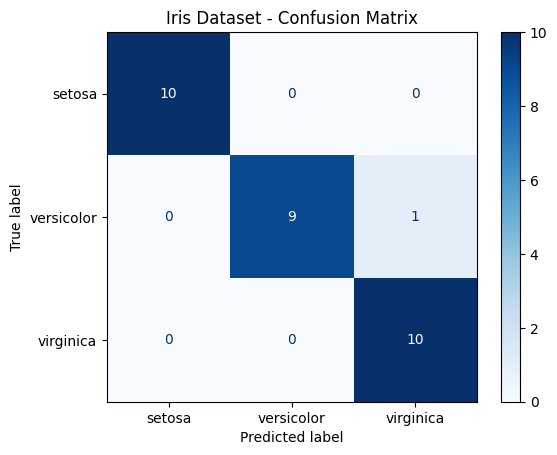

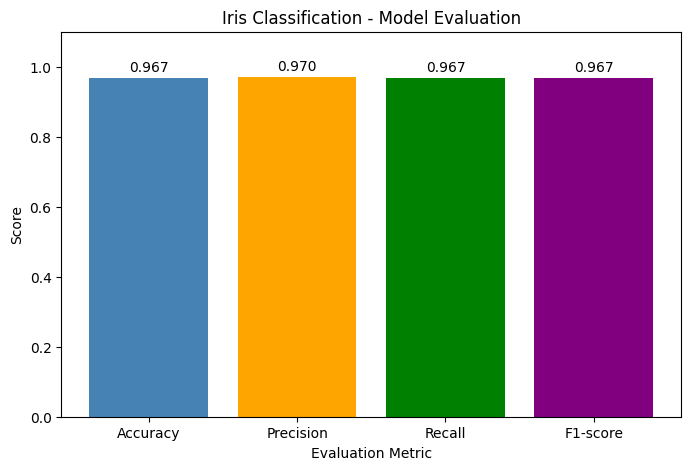

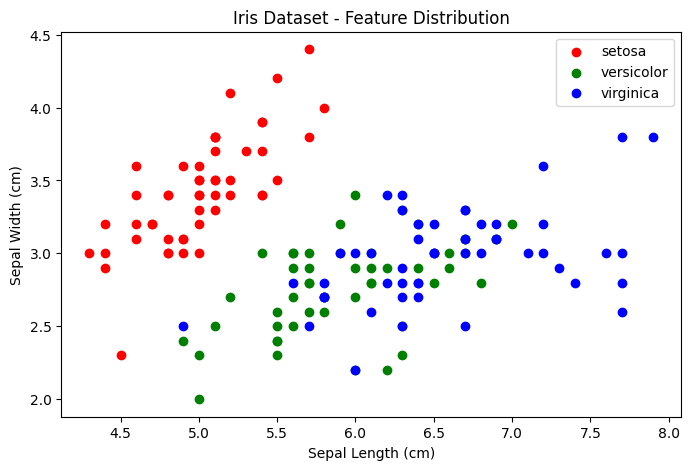

In [1]:
# ============================================================
# BASIC SUPERVISED LEARNING PIPELINE
# DATASET: IRIS
# CLASSIFIER: DECISION TREE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# ============================================================
# 1. LOAD IRIS DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("=" * 60)
print("IRIS DATASET")
print("=" * 60)

print("\nFeatures:")
print(feature_names)

print("\nTarget classes:")
print(target_names)

print("\nNumber of samples:", len(X))


# ============================================================
# 2. CONVERT TO DATAFRAME
# ============================================================

df = pd.DataFrame(
    X,
    columns=feature_names
)

df["Species"] = [
    target_names[i]
    for i in y
]

print("\nFirst 10 records:")
print(df.head(10))


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 4. CREATE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)


# ============================================================
# 5. TRAIN MODEL
# ============================================================

model.fit(
    X_train,
    y_train
)

print("\nModel training completed.")


# ============================================================
# 6. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nActual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)


# ============================================================
# 7. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


# ============================================================
# 8. CALCULATE PRECISION
# ============================================================

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 9. CALCULATE RECALL
# ============================================================

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 10. CALCULATE F1 SCORE
# ============================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 11. DISPLAY EVALUATION METRICS
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# ============================================================
# 14. CONFUSION MATRIX GRAPH
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Iris Dataset - Confusion Matrix")
plt.show()


# ============================================================
# 15. METRICS GRAPH
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics,
    values,
    color=[
        "steelblue",
        "orange",
        "green",
        "purple"
    ]
)

plt.ylim(0, 1.1)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title(
    "Iris Classification - Model Evaluation"
)

# Display values on bars
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.show()


# ============================================================
# 16. FEATURE DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

colors = [
    "red",
    "green",
    "blue"
]

for i, species in enumerate(target_names):

    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        label=species,
        color=colors[i]
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.title(
    "Iris Dataset - Feature Distribution"
)

plt.legend()

plt.show()
